ADP论文的开源代码(改进特征工程)只去掉时间戳，其他不变


# Downloading and Reading the CSI Dataset

In [1]:
# Use the following commands to download parts of the dichasus-cf0x dataset.
# This tutorial uses the "old" dataset version (not "rev2") - do not manually download the dataset from the website.
# If you need to manually download the dataset from your browser, please use this website instead:
# https://darus.uni-stuttgart.de/dataset.xhtml?persistentId=doi:10.18419/DARUS-2854&version=2.0
# !mkdir dichasus
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/8 -P dichasus # dichasus-cf02
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/9 -P dichasus # dichasus-cf03
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/10 -P dichasus # dichasus-cf04
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf02.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf03.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf04.json -P dichasus

In [1]:
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import trustworthiness
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import distance_matrix
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm.auto import tqdm
import tensorflow as tf
import numpy as np
import random
import queue
import json
        

# Antenna definitions
ASSIGNMENTS = [
    [0, 13, 31, 29, 3, 7, 1, 12 ],
    [30, 26, 21, 25, 24, 8, 22, 15],
    [28, 5, 10, 14, 6, 2, 16, 18],
    [19, 4, 23, 17, 20, 11, 9, 27]
]

ANTENNACOUNT = np.sum([len(antennaArray) for antennaArray in ASSIGNMENTS])

def load_calibrate_timedomain(path, offset_path):
    offsets = None
    with open(offset_path, "r") as offsetfile:
        offsets = json.load(offsetfile)
    
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )

        csi = tf.ensure_shape(tf.io.parse_tensor(record["csi"], out_type=tf.float32), (ANTENNACOUNT, 1024, 2))   #CSI向量（32，1024，2）
        csi = tf.complex(csi[:, :, 0], csi[:, :, 1])   #合并为复数 （32，1024）
        csi = tf.signal.fftshift(csi, axes=1)  #FFT移位，0频率移到中心

        position = tf.ensure_shape(tf.io.parse_tensor(record["pos-tachy"], out_type=tf.float64), (3))
        time = tf.ensure_shape(record["time"], ())

        return csi, position[:2], time

    def apply_calibration(csi, pos, time):
        sto_offset = tf.tensordot(tf.constant(offsets["sto"]), 2 * np.pi * tf.range(tf.shape(csi)[1], dtype = np.float32) / tf.cast(tf.shape(csi)[1], np.float32), axes = 0)
        cpo_offset = tf.tensordot(tf.constant(offsets["cpo"]), tf.ones(tf.shape(csi)[1], dtype = np.float32), axes = 0)
        csi = tf.multiply(csi, tf.exp(tf.complex(0.0, sto_offset + cpo_offset)))

        return csi, pos, time

    def csi_time_domain(csi, pos, time):
        csi = tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi, axes=1)),axes=1)

        return csi, pos, time

    def cut_out_taps(tap_start, tap_stop):
        def cut_out_taps_func(csi, pos, time):
            return csi[:,tap_start:tap_stop], pos, time

        return cut_out_taps_func

    def order_by_antenna_assignments(csi, pos, time):
        csi = tf.stack([tf.gather(csi, antenna_inidces) for antenna_inidces in ASSIGNMENTS])
        return csi, pos, time
    
    dataset = tf.data.TFRecordDataset(path)
    
    dataset = dataset.map(record_parse_function, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(apply_calibration, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(csi_time_domain, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(cut_out_taps(507, 520), num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(order_by_antenna_assignments, num_parallel_calls = tf.data.AUTOTUNE)

    return dataset

inputpaths = [
    {
        "tfrecords" : "dichasus/dichasus-cf02.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf02.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-cf03.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf03.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-cf04.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf04.json"
    }
]

full_dataset = load_calibrate_timedomain(inputpaths[0]["tfrecords"], inputpaths[0]["offsets"])

for path in inputpaths[1:]:
    full_dataset = full_dataset.concatenate(load_calibrate_timedomain(path["tfrecords"], path["offsets"]))

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-14 01:44:24.826340: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 01:44:24.893565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 01:44:26.178298: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sl

In [22]:
# Decimate dataset: Use only every 4th datapoint (to reduce number of points)
training_set = full_dataset.shard(4, 2)

# From TensorFlow to NumPy

转换原因：
1.传统机器学习库的需要，大多数scikit-learn算法需要numpy数组输入；科学计算生态系统的兼容
2.numpy针对CPU操作优化，可以一次性加载到内存，对于小到中等数据集内存缓存可以加速迭代
3.tensorflow在调试的时候不方便，需要eval或numpy才能看到值

In [23]:
groundtruth_positions = []
csi_time_domain = []
timestamps = []

for csi, pos, time in training_set.batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())
    timestamps.append(time.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)
timestamps = np.concatenate(timestamps)

2026-01-14 01:53:13.519193: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Visualizing the Dataset

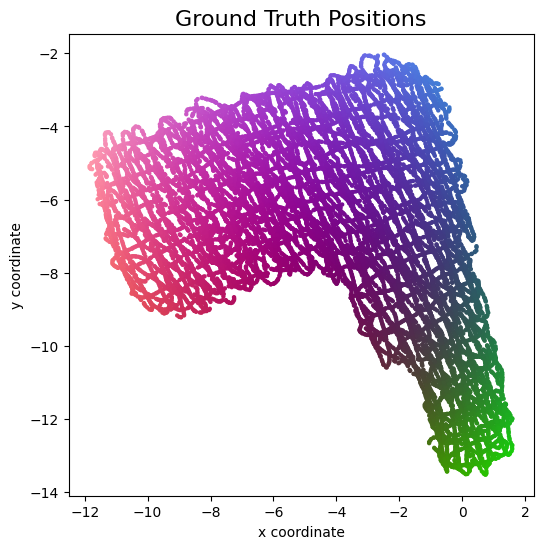

In [4]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    NormalizeData = lambda in_data : (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

plot_colorized(groundtruth_positions, groundtruth_positions, title="Ground Truth Positions")

# Dissimilarity Metrics and Dissimilarity Matrix Computation

### Step 1: ADP-based dissimilarity matrix

In [24]:
adp_dissimilarity_matrix = np.zeros((csi_time_domain.shape[0], csi_time_domain.shape[0]),dtype=np.float32)

def adp_dissimilarities_worker(todo_queue, output_queue):
    def adp_dissimilarities(index):
        # h has shape (arrays, antennas, taps), w has shape (datapoints, arrays, antennas, taps)
        h = csi_time_domain[index,:,:,:]
        w = csi_time_domain[index:,:,:,:]
            
        dotproducts = np.abs(np.einsum("bmt,lbmt->lbt", np.conj(h), w, optimize = "optimal"))**2
        norms = np.real(np.einsum("bmt,bmt->bt", h, np.conj(h), optimize = "optimal") * np.einsum("lbmt,lbmt->lbt", w, np.conj(w), optimize = "optimal"))
        
        return np.sum(1 - dotproducts / norms, axis = (1, 2))

    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break
        
        output_queue.put((index, adp_dissimilarities(index)))

with tqdm(total = csi_time_domain.shape[0]**2) as pbar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(csi_time_domain.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = adp_dissimilarities_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            adp_dissimilarity_matrix[i,i:] = d
            adp_dissimilarity_matrix[i:,i] = d
            pbar.update(2 * len(d) - 1)

100%|██████████| 440832016/440832016 [00:57<00:00, 7615369.99it/s] 


### Step 2: Timestamp-based dissimilarity matrix

In [6]:
# Compute timestamp-based dissimilarity matrix
timestamp_dissimilarity_matrix = np.abs(np.subtract.outer(timestamps, timestamps))

### Step 3: Fusing $\mathbf D_\mathrm{ADP}$ with $\mathbf D_\mathrm{time}$

Text(0, 0.5, 'Number of Occurences')

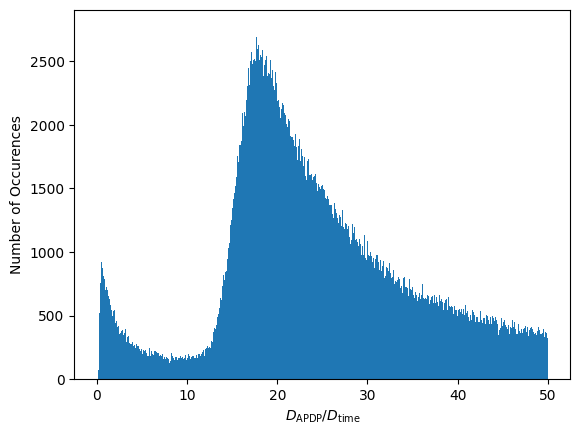

In [8]:
TIME_THRESHOLD = 2
small_time_dissimilarity_indices = np.logical_and(timestamp_dissimilarity_matrix < TIME_THRESHOLD, timestamp_dissimilarity_matrix > 0)
small_time_dissimilarities = timestamp_dissimilarity_matrix[small_time_dissimilarity_indices]
small_adp_dissimilarities = adp_dissimilarity_matrix[small_time_dissimilarity_indices]

n_bins = 1500

fig, ax1 = plt.subplots()
occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)
ax1.set_xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
ax1.set_ylabel("Number of Occurences")

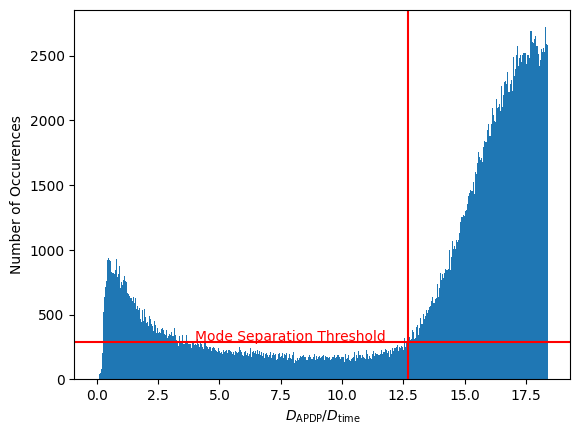

gamma =  12.683333396911621


In [9]:
bin_centers = edges[:-1] + np.diff(edges) / 2.
max_bin = np.argmax(occurences)
min_threshold = np.quantile(occurences[:max_bin], 0.5)

for threshold_bin in range(max_bin - 1, -1, -1):
    if occurences[threshold_bin] < min_threshold:
        break

scaling_factor = bin_centers[threshold_bin]

plt.bar(bin_centers[:max_bin], occurences[:max_bin], width = edges[1] - edges[0])
plt.axhline(y = min_threshold, color = 'r', linestyle = '-')
plt.text(4, min_threshold + 10, "Mode Separation Threshold", color = 'r',)
plt.axvline(x = scaling_factor, color = 'r', linestyle = '-')
plt.xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
plt.ylabel("Number of Occurences")
plt.show()

print("gamma = ", scaling_factor)

In [10]:
# Fuse ADP-based and time-based dissimilarity matrices
dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)

In [25]:
dissimilarity_matrix_fused = adp_dissimilarity_matrix

### Step 4: Geodesic Dissimilarity Matrix

In [26]:
n_neighbors = 20

nbrs_alg = NearestNeighbors(n_neighbors = n_neighbors, metric="precomputed", n_jobs = -1)
nbrs = nbrs_alg.fit(dissimilarity_matrix_fused)
nbg = kneighbors_graph(nbrs, n_neighbors, metric = "precomputed", mode="distance")

In [27]:
dissimilarity_matrix_geodesic = np.zeros((nbg.shape[0], nbg.shape[1]), dtype = np.float32)

def shortest_path_worker(todo_queue, output_queue):
    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break

        d = dijkstra(nbg, directed=False, indices=index)
        output_queue.put((index, d))

with tqdm(total = nbg.shape[0]**2) as pbar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(nbg.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = shortest_path_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            dissimilarity_matrix_geodesic[i,:] = d
            pbar.update(len(d))

100%|██████████| 440832016/440832016 [00:36<00:00, 12245265.49it/s] 


In [28]:
# Compute distances between groundtruth positions
groundtruth_distance_matrix = distance_matrix(groundtruth_positions, groundtruth_positions)

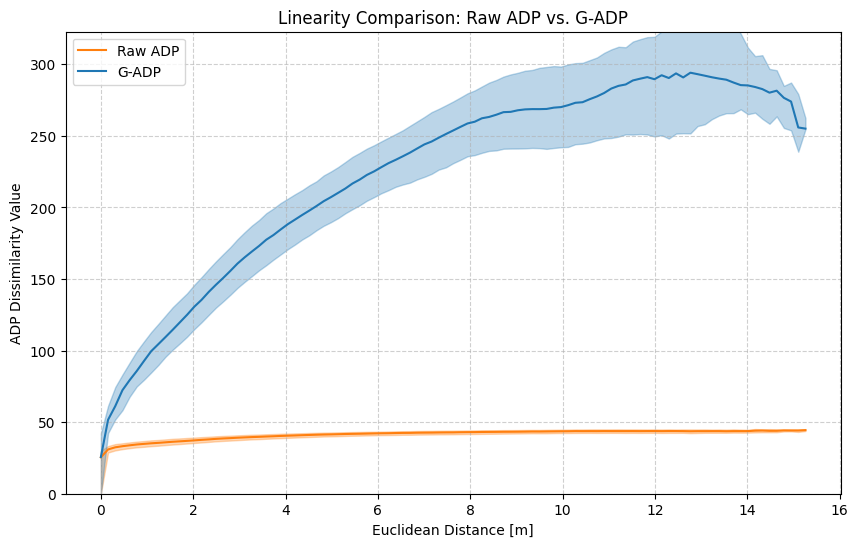

In [29]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None, color = None):
    nth_reduction = 10
    # 过滤掉 inf 值（Dijkstra 可能产生的不可达点）
    dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
    distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
    
    mask = np.isfinite(dissimilarities_flat)
    dissimilarities_flat = dissimilarities_flat[mask]
    distances_flat = distances_flat[mask]
    
    max_distance = np.max(distances_flat)
    bins = np.linspace(0, max_distance, 100)
    bin_indices = np.digitize(distances_flat, bins)
    
    bin_medians = np.zeros(len(bins) - 1)
    bin_25_perc = np.zeros(len(bins) - 1)
    bin_75_perc = np.zeros(len(bins) - 1)
    
    for i in range(1, len(bins)):
        bin_values = dissimilarities_flat[bin_indices == i]
        if len(bin_values) > 0:
            bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75])
    
    plt.plot(bins[:-1], bin_medians, label = label, color = color)
    plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, color = color, alpha=0.3)

plt.figure(figsize=(10, 6))

# 1. 绘制原始 ADP 曲线 (Raw ADP)
# 此时不乘以 scaling_factor，直接反映特征空间的原始距离
plot_dissimilarity_over_euclidean_distance(adp_dissimilarity_matrix, groundtruth_distance_matrix, "Raw ADP", "tab:orange")

# 2. 绘制经过测地线优化的 ADP 曲线 (G-ADP)
# 这里的 dissimilarity_matrix_geodesic 是由 adp_dissimilarity_matrix 计算得到的
plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-ADP", "tab:blue")

plt.legend()
plt.title("Linearity Comparison: Raw ADP vs. G-ADP")
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("ADP Dissimilarity Value") # 这里的 label 建议改为原始值

# 动态设置纵轴范围，避免噪声导致刻度过大
max_y = np.percentile(dissimilarity_matrix_geodesic[np.isfinite(dissimilarity_matrix_geodesic)], 98)
plt.ylim(0, max_y)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1.降采样与展平，减少计算量，并把二维矩阵拉平为一维数组
2.基于物理距离分箱
3.计算箱内统计量，提取落在这个距离范围的所有差异度数值，计算中位数和上下四分位数。中位数-代表这个物理距离下的典型差异度；25%和75%代表数据的离散程度。实线绘制中位数曲线，阴影带填充表示该方法的不确定性。
评价：
理想状态-线性上升，阴影带窄；ADP曲线，短距离上升快但很快变平，说明只能感知局部相似性，两点超过一定范围ADP差异度都接近1，无法区分远近，不适合全局定位。
G-fuse解决了远距离不可测的问题，将度量范围扩展到全局。

# Manifold Learning: Finding the Low-Dimensional Representation

### The First Channel Chart: MDS / Isomap

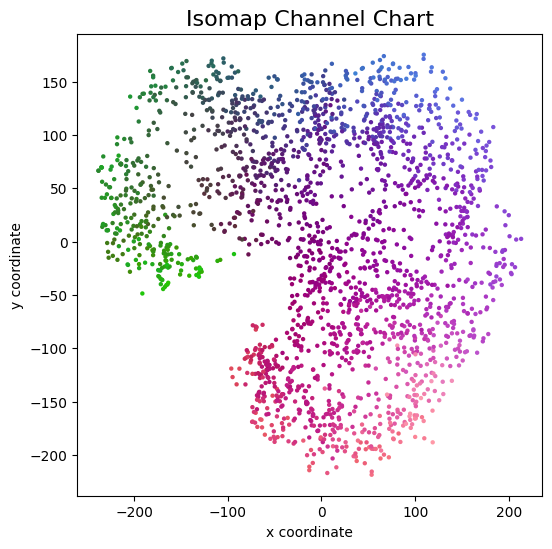

In [12]:
nth_reduction = 10

reduced_dissimilarity_matrix_geodesic = dissimilarity_matrix_geodesic[::nth_reduction, ::nth_reduction]
embedding_isomap = MDS(metric = True, dissimilarity = "precomputed", max_iter = 300, normalized_stress = False)
proj_isomap = embedding_isomap.fit_transform(reduced_dissimilarity_matrix_geodesic)
plot_colorized(proj_isomap, groundtruth_positions[::nth_reduction], title = "Isomap Channel Chart")
#颜色基于真实位置，坐标基于Isomap，作弊?

### Feature Engineering

当前问题：保留 13个抽头分别计算矩阵是冗余的，且容易引入多径噪声。
改进方法：计算时间平均的空间协方差矩阵。即在计算相关性时，对抽头维度求和或平均。将物理意义从每个瞬间的瞬时相关转变为统计上的空间信道特征
这一步能极大压缩数据量，同时增强特征的鲁棒性（降噪）

In [11]:
class FeatureEngineeringLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(FeatureEngineeringLayer, self).__init__(dtype = tf.complex64)

    def call(self, csi):
        # 输入 csi 形状: (Batch, Array, Antenna, Tap)
        # 也就是 (d, a, m, t)
        
        # 改进逻辑：
        # 1. 计算全系统的空间协方差矩阵 (Spatial Covariance Matrix)。
        # 2. 关键改变：在 't' (Tap) 维度上求和 (Summation)。
        #    指令从 "damt,dbnt->dtabmn" 改为 "damt,dbnt->dabmn"
        #    这将消除时间维度，只保留纯粹的空间角度特征。
        
        # 计算 R = H * H^H (沿时间轴 t 累加)
        spatial_covariance = tf.einsum("damt,dbnt->dabmn", csi, tf.math.conj(csi))
        
        # 归一化 (可选，除以抽头数量，使数值不随抽头数变化)
        # tap_count = tf.cast(tf.shape(csi)[-1], dtype=tf.complex64)
        # spatial_covariance = spatial_covariance / tap_count

        # 提取实部和虚部堆叠
        # 输出形状将变为: (Batch, 4, 4, 8, 8, 2)
        return tf.stack([tf.math.real(spatial_covariance), tf.math.imag(spatial_covariance)], axis = -1)

### The Forward Charting Function: Defining the Neural Network

In [30]:
array_count = np.shape(csi_time_domain)[1]
antenna_per_array_count = np.shape(csi_time_domain)[2]
tap_count = np.shape(csi_time_domain)[3]

cc_embmodel_input = tf.keras.Input(shape=(array_count, antenna_per_array_count, tap_count), name="input", dtype = tf.complex64)
cc_embmodel_output = FeatureEngineeringLayer()(cc_embmodel_input)
cc_embmodel_output = tf.keras.layers.Flatten()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(1024, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(512, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(256, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(128, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(64, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(2, activation = "linear")(cc_embmodel_output)

cc_embmodel = tf.keras.Model(inputs=cc_embmodel_input, outputs=cc_embmodel_output, name = "ForwardChartingFunction")

### Siamese Neural Network

In [31]:
dissimilarity_margin = np.quantile(dissimilarity_matrix_geodesic, 0.01)

def siamese_loss(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1,))
    pos_A, pos_B = (y_pred[:,:2], y_pred[:,2:])
    distances_pred = tf.math.sqrt(tf.math.reduce_sum(tf.square(pos_A - pos_B), axis = 1))

    return tf.reduce_mean(tf.square(distances_pred - y_true) / (y_true + dissimilarity_margin))

In [32]:
input_A = tf.keras.layers.Input(shape = (array_count, antenna_per_array_count, tap_count,), dtype = tf.complex64)
input_B = tf.keras.layers.Input(shape = (array_count, antenna_per_array_count, tap_count,), dtype = tf.complex64)

embedding_A = cc_embmodel(input_A)
embedding_B = cc_embmodel(input_B)

output = tf.keras.layers.concatenate([embedding_A, embedding_B], axis=1)
model = tf.keras.models.Model([input_A, input_B], output, name = "SiameseNeuralNetwork")

### Sample Selection

In [33]:
csi_time_domain_tensor = tf.constant(csi_time_domain)
dissimilarity_matrix_geodesic_tensor = tf.constant(dissimilarity_matrix_geodesic)

datapoint_count = tf.shape(csi_time_domain_tensor)[0].numpy()

random_integer_pairs_dataset = tf.data.Dataset.zip(tf.data.Dataset.random(), tf.data.Dataset.random())

@tf.function
def fill_pairs(randA, randB):
    return (csi_time_domain_tensor[randA % datapoint_count], csi_time_domain_tensor[randB % datapoint_count]), dissimilarity_matrix_geodesic_tensor[randA % datapoint_count, randB % datapoint_count]

random_pair_dataset = random_integer_pairs_dataset.map(fill_pairs)

### Training


Training Session  1 
Batch Size:  500 
Learning rate:  0.01
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 62.1477
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


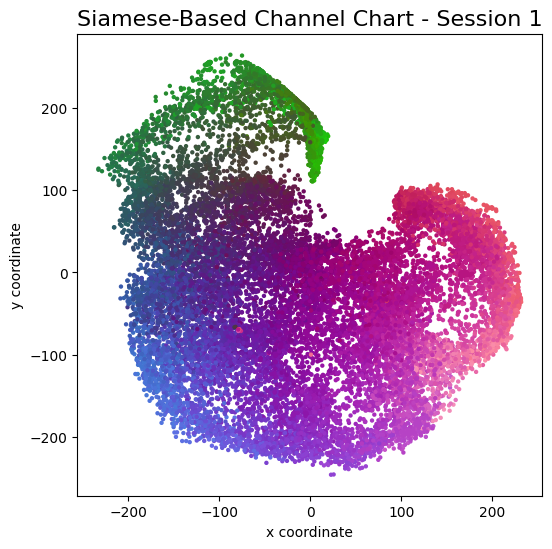


Training Session  2 
Batch Size:  1000 
Learning rate:  0.01
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 8.7028
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


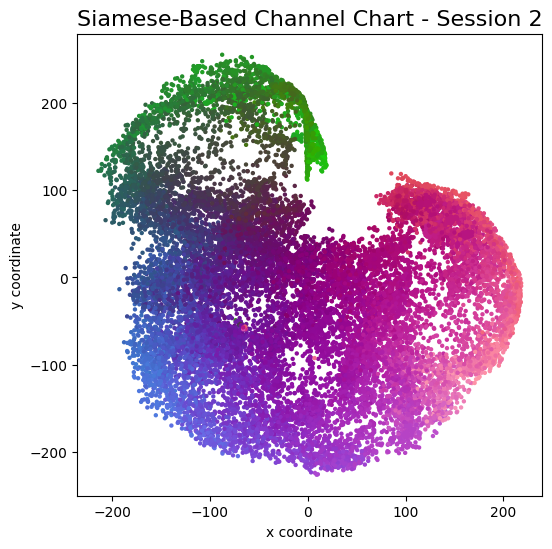


Training Session  3 
Batch Size:  1500 
Learning rate:  0.008
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 8.4128
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


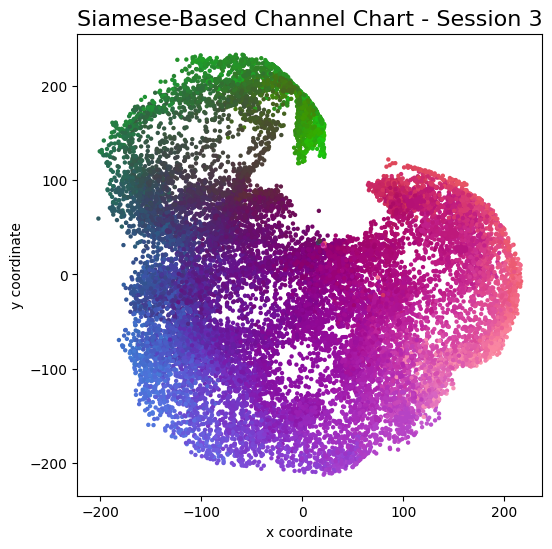


Training Session  4 
Batch Size:  2000 
Learning rate:  0.004
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 8.2208
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


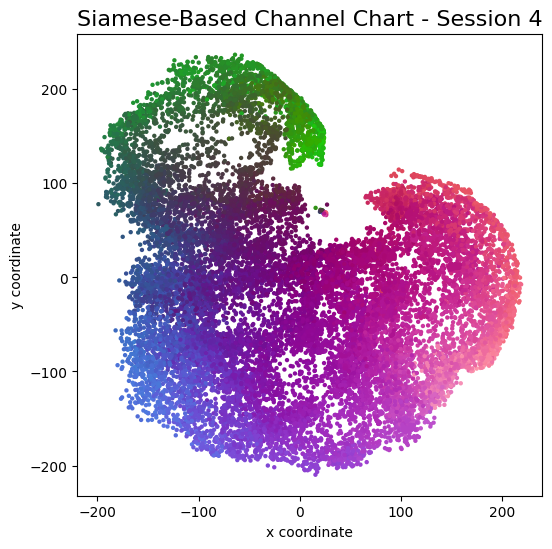


Training Session  5 
Batch Size:  3000 
Learning rate:  0.001
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 8.0806
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


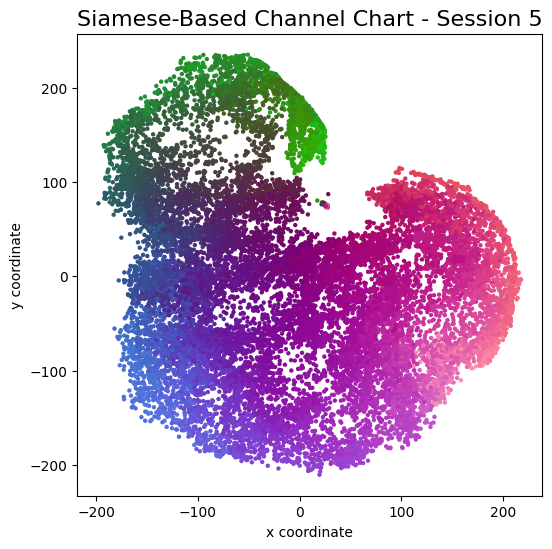


Training Session  6 
Batch Size:  4000 
Learning rate:  0.0005
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 8.0399
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


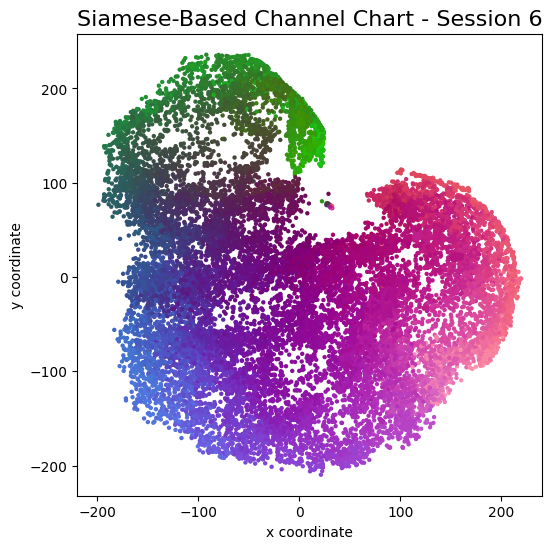


Training Session  7 
Batch Size:  5000 
Learning rate:  0.0002
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 7.9604
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


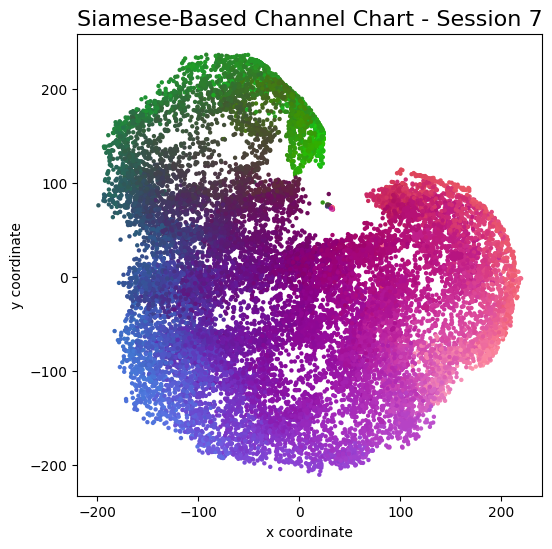


Training Session  8 
Batch Size:  6000 
Learning rate:  0.0001
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 7.9726
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


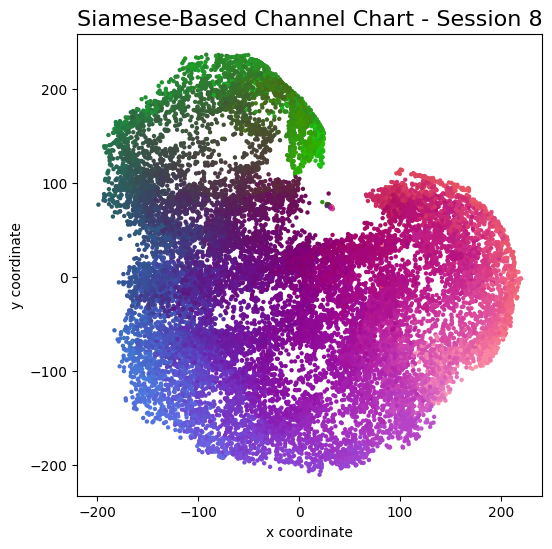

In [35]:
optimizer = tf.keras.optimizers.Adam()
model.compile(loss = siamese_loss, optimizer = optimizer)

samples_per_session = 150000
learning_rates = [1e-2, 1e-2, 8e-3, 4e-3, 1e-3, 5e-4, 2e-4, 1e-4]
batch_size = [500, 1000, 1500, 2000, 3000, 4000, 5000, 6000]

for l in range(len(learning_rates)):
    print("\nTraining Session ", l + 1, "\nBatch Size: ", batch_size[l], "\nLearning rate: ", learning_rates[l])

    # Fit model
    optimizer.learning_rate.assign(learning_rates[l])
    model.fit(random_pair_dataset.batch(batch_size[l]).prefetch(tf.data.AUTOTUNE), steps_per_epoch = samples_per_session // batch_size[l])

    # Plot Channel Chart
    print("Running inference to plot channel chart")
    channel_chart_positions = cc_embmodel.predict(csi_time_domain)
    plot_colorized(channel_chart_positions, groundtruth_positions, title = "Siamese-Based Channel Chart - Session " + str(l + 1))

# Evaluation: Optimal Affine Transform and Mean Absolute Error

657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


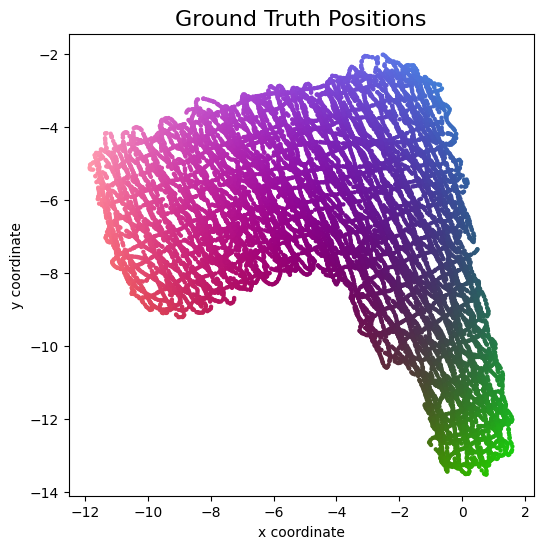

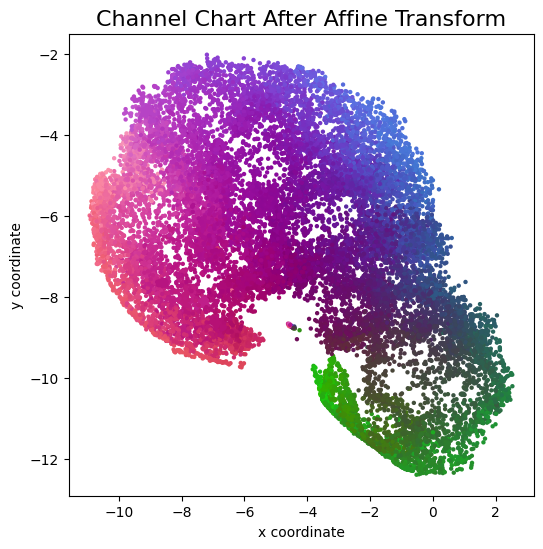

In [36]:
channel_chart_positions = cc_embmodel.predict(csi_time_domain)

def affine_transform_channel_chart(groundtruth_pos, channel_chart_pos):
    pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
    unpad = lambda x: x[:,:-1]
    A, res, rank, s = np.linalg.lstsq(pad(channel_chart_pos), pad(groundtruth_pos), rcond = None)
    transform = lambda x: unpad(np.dot(pad(x), A))
    return transform(channel_chart_pos)

channel_chart_positions_transformed = affine_transform_channel_chart(groundtruth_positions, channel_chart_positions)
plot_colorized(groundtruth_positions, groundtruth_positions, title = "Ground Truth Positions")
plot_colorized(channel_chart_positions_transformed, groundtruth_positions, title = "Channel Chart After Affine Transform")

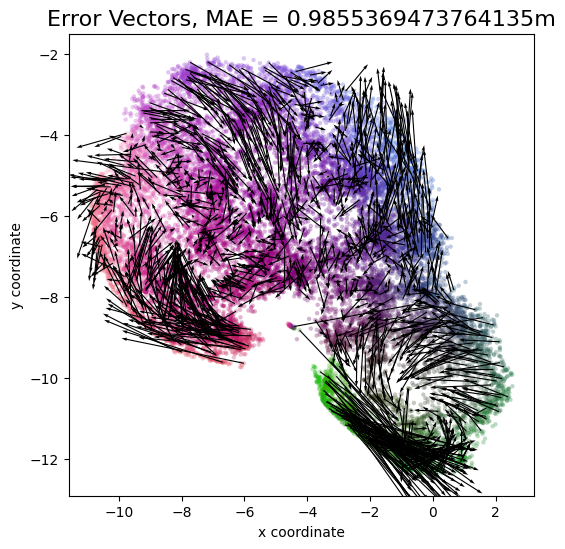

In [37]:
errorvectors = groundtruth_positions - channel_chart_positions_transformed
errors = np.sqrt(errorvectors[:,0]**2 + errorvectors[:,1]**2)
mae = np.mean(errors)

nth_errorvector = 15
plot_colorized(channel_chart_positions_transformed, groundtruth_positions, title = "Error Vectors, MAE = " + str(mae) + "m", show = False, alpha = 0.3)
plt.quiver(channel_chart_positions_transformed[::nth_errorvector, 0], channel_chart_positions_transformed[::nth_errorvector, 1], errorvectors[::nth_errorvector, 0], errorvectors[::nth_errorvector, 1], color = "black", angles = "xy", scale_units = "xy", scale = 1)
plt.show()

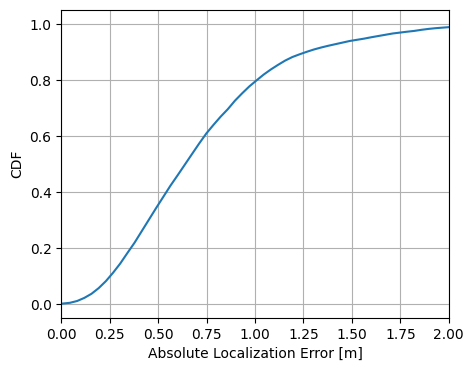

In [19]:
count, bins_count = np.histogram(errors, bins=200)
pdf = count / sum(count)
cdf = np.cumsum(pdf)

bins_count[0] = 0
cdf = np.append([0], cdf)

plt.figure(figsize=(5, 4))
plt.plot(bins_count, cdf)
plt.xlim((0, 2))
plt.xlabel("Absolute Localization Error [m]")
plt.ylabel("CDF")
plt.grid()
plt.show()

# Evaluation: Continuity, Trustworthiness, Kruskal Stress

In [20]:
# Continuity is identical to trustworthiness, except that original space and embedding space are swapped
def continuity(*args, **kwargs):
    args = list(args)
    args[0], args[1] = args[1], args[0]
    return trustworthiness(*args, **kwargs)

def kruskal_stress(X, X_embedded):
    dist_X = distance_matrix(X, X)
    dist_X_embedded = distance_matrix(X_embedded, X_embedded)
    beta = np.divide(np.sum(dist_X * dist_X_embedded), np.sum(dist_X_embedded * dist_X_embedded))

    return np.sqrt(np.divide(np.sum(np.square((dist_X - beta * dist_X_embedded))), np.sum(dist_X * dist_X)))

In [38]:
# Evaluate CT / TW / KS on a subset of the whole dataset
subset_indices = random.sample(range(len(groundtruth_positions)), len(groundtruth_positions) // 5)
groundtruth_positions_subset = groundtruth_positions[subset_indices]
channel_chart_positions_subset = channel_chart_positions[subset_indices]

ct = continuity(groundtruth_positions_subset, channel_chart_positions_subset, n_neighbors = int(0.05 * len(groundtruth_positions_subset)))
tw = trustworthiness(groundtruth_positions_subset, channel_chart_positions_subset, n_neighbors = int(0.05 * len(groundtruth_positions_subset)))
ks = kruskal_stress(groundtruth_positions_subset, channel_chart_positions_subset)

print("CT: {} \nTW: {} \nKS: {}".format(*np.around((ct, tw, ks), 4)))

CT: 0.985 
TW: 0.9833 
KS: 0.2257
